# **Question 1: Programming Exercise**

Run the provided code snippet to download 1 year of daily opening and closing prices and present them in graphical form.

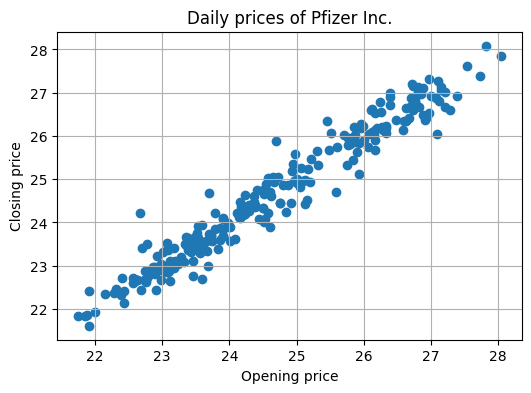

In [1]:
import yfinance as yf
import numpy as np

# create Ticker object which will allow data access
data = yf.Ticker("PFE")

# Download 1 year of price data
hist = data.history(period="1y")

# Store daily opening and closing prices
x = np.array(hist["Open"])
y = np.array(hist["Close"])

# Plot closing prices
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize = (6,4))
ax.set(title = f"Daily prices of {data.info['longName']}",
ylabel = "Closing price", xlabel = "Opening price")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
ax.scatter(x, y)
plt.show()

Notice that there appears to be some linear relationship between the daily opening and closing prices. Taking $y_i$ to be the daily closing price and $x_i$ to be the daily opening price, a linear model to represent this relationship can be expressed as $$y_i = \alpha + \beta x_i + \varepsilon_i$$ for all $i$, where $\varepsilon_i$ is the error.

The least squares estimates of the parameters $\alpha$ and $\beta$ is

$$\hat{\beta}=\frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}{\sum_{i=1}^{n}(x_i-\bar{x})^2},\,\,\hat{\alpha}=\bar{y}-\hat{\beta}\bar{x}$$

where

$$\bar{x}=\frac{1}{n}\sum_{i=1}^{n}x_i,\,\,\bar{y}=\frac{1}{n}\sum_{i=1}^{n}y_i.$$

## Exercise 1
(Coding task: 10% of project mark). Write a function that calculates the least squares estimates $\hat{\alpha}$ and $\hat{\beta}$.

Your function should take two arguments, the NumPy arrays x and y, and it should return the estimatesd as a tuple.

For full marks you should:
- Test whether x and y are the same (non-zero) length, and terminate with suitable error message if they are not.
- Use vectorized and/ or built-in NumPy methods where appropriate. Provide references for NumPy methods used where not covered in the course materials.
- Be efficient.

Report the values of $\hat{\alpha}$ and $\hat{\beta}$ for the daily opening and closing prices of Pfizer stock downloaded above.

In [2]:
# References for NumPy methods used in my code:
# np.dot : Dot product between two arrays
# https://numpy.org/doc/stable/reference/generated/numpy.dot.html

# np.mean : mean of an array
# https://numpy.org/doc/stable/reference/generated/numpy.mean.html

# np.sum : sum of two arrays
# https://numpy.org/doc/stable/reference/generated/numpy.sum.html

import numpy as np

def LS(x, y):
  """The LS function generates the least squares estimates of
  two input arrays x and y. Both arrays must have equal and
  non-zero length.
  Arguments:
    x: numpy array of x-coordinates
    y: numpy array of y-coordinates
  Returns:
    alpha: intercept estimate
    beta: gradient estimate
  """
  x = np.asarray(x)
  y = np.asarray(y)

  if len(x) != len(y):
    print("Error: Inputs arrays must have equal length")
    return None, None
  if len(x) == 0:
    print("Error: Input arrays must have non-zero length")
    return None, None

  bx = np.mean(x)
  by = np.mean(y)

  beta = np.dot((x - bx) , (y - by)) / np.sum((x - bx)**2)
  alpha = by - beta * bx

  return alpha, beta

a, b = LS(x, y)

print(f"Our least squares approximation returns the coefficients\nAlpha = {a:.4f}\nBeta = {b:.4f}\n")

Our least squares approximation returns the coefficients
Alpha = 0.5486
Beta = 0.9776



## Supplementary Plot
This section is supplementary and not to be marked.

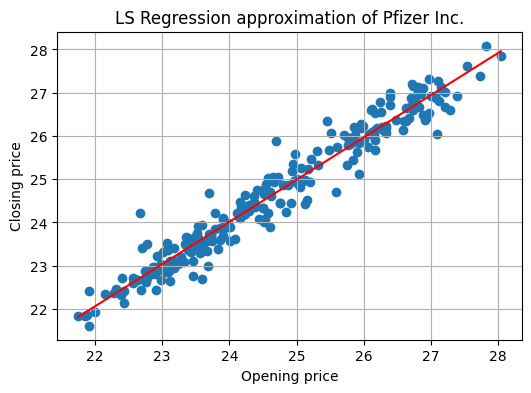

In [3]:
# Do not mark this section

# We can plot our least squares regression line using matplotlib
import matplotlib.pyplot as plt

def showline(x, y):
  """The showline function plots the regression approximation on a graph"""
  c, m = LS(x, y)
  p = np.linspace(min(x), max(x), 2)
  q = m * p + c
  fig, ax = plt.subplots(figsize = (6,4))
  ax.set(title = f"LS Regression approximation of {data.info['longName']}",
  ylabel = "Closing price", xlabel = "Opening price")
  ax.xaxis.grid(True)
  ax.yaxis.grid(True)
  ax.scatter(x, y)
  plt.plot(p, q, color = 'red')
  plt.show()

showline(x, y)